In [1]:
# global sky model for cassata
# based on https://iopscience.iop.org/article/10.3847/2515-5172/ac332c

In [35]:
import sys
from pylab import *

In [4]:
sys.version

'3.10.13 (main, Nov 23 2023, 10:13:54) [GCC 7.5.0]'

In [7]:
!pip install pygdsm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 11.5 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.8 MB/s eta 0:00:00
  Created wheel for pyephem: filename=pyephem-9.99-py3-none-any.whl size=1551 sha256=d4ae96f8e1e2ea52481e376dccaa03552e19350c47882c47b70ab8d284f6f2a7
  Stored in directory: /home/ban115/.cache/pip/wheels/ea/79/dc/3e213ee6fffc865c0e7c59365e4adcc4b5579efe1a47c8c524
Successfully built pyephem


In [9]:
import pygdsm

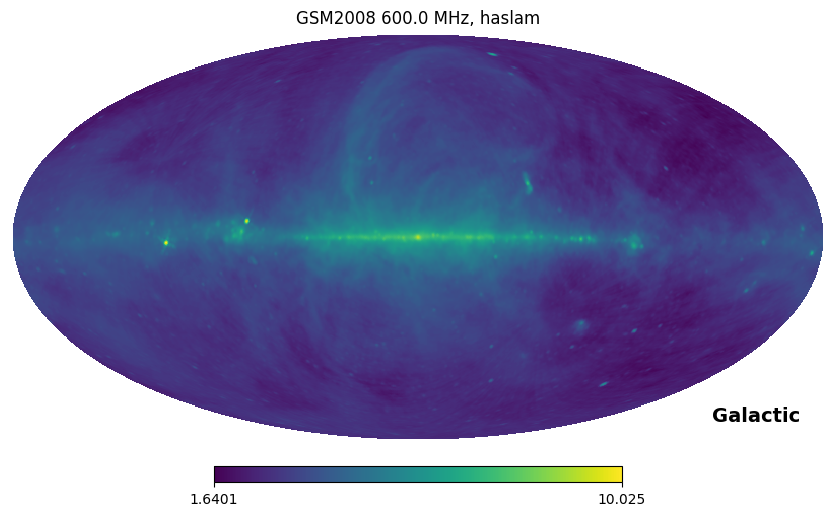

In [38]:
# Import packages
import numpy as np
import pygdsm
from pygdsm import GlobalSkyModel
from astropy.coordinates import SkyCoord
 
# Setup observing frequency and pointing direction
freqs_mhz = np.array([600,700,800]) # In MHz
sky_coord = SkyCoord("17h29m", "-2d7m", unit = ('hourangle', 'degree'), frame = 'galactic')
 
# Generate T_sky from GSM
gsm = GlobalSkyModel()
sky = gsm.generate(600)
gsm.view(logged=True)
T_sky = np.array(gsm.get_sky_temperature(sky_coord, freqs_mhz))

(0.0, 100.0)

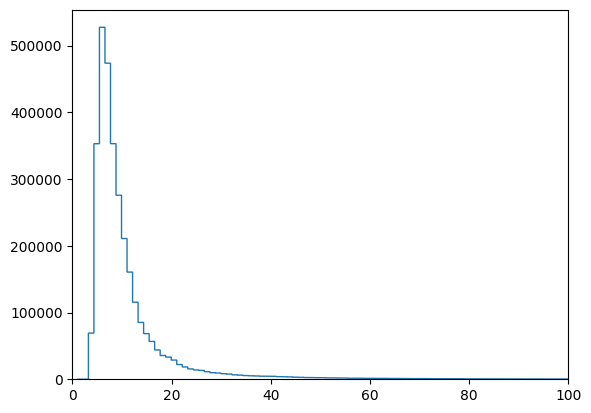

In [41]:
_ = hist(sky,bins=1000, histtype='step')
xlim(0,100)

In [26]:
x = gsm.generate(100)

In [27]:
gsm.data_unit

'K'

In [43]:
np.median(sky)

8.139320307702558

In [116]:
freqs = np.linspace(200,800,20)
skytemps = []
for f in freqs:
    gsm = GlobalSkyModel()
    sky = gsm.generate(f)
    skytemps.append(sky)
    
skytemps = np.array(skytemps)

Text(0.5, 1.0, 'Global sky model median sky temperature (K)')

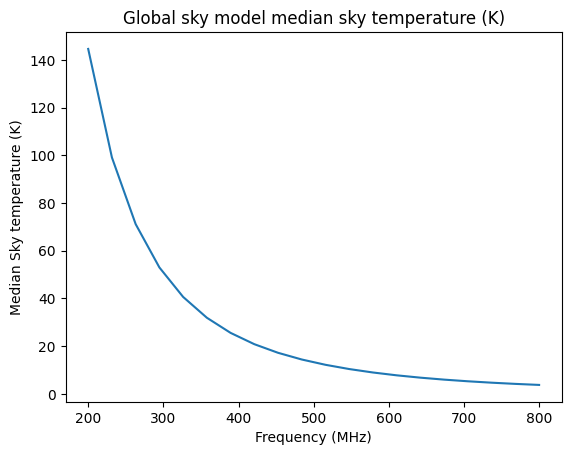

In [117]:
medskytemps = np.median(skytemps, axis=1)
plot(freqs, medskytemps)
xlabel('Frequency (MHz)')
ylabel('Median Sky temperature (K)')
title('Global sky model median sky temperature (K)')

In [118]:
lambdas = constants.c/(freqs *1e6)
lambdas

array([1.49896229, 1.29455834, 1.13921134, 1.01715298, 0.91871882,
       0.8376554 , 0.76973739, 0.71200709, 0.66233217, 0.6191366 ,
       0.58123028, 0.54769776, 0.51782334, 0.49103937, 0.46688989,
       0.44500443, 0.42507886, 0.40686119, 0.39014087, 0.37474057])

In [119]:
aeff = lambdas**2/(4*np.pi)
aeff

array([0.17880166, 0.1333624 , 0.10327584, 0.08233087, 0.06716691,
       0.05583685, 0.04714931, 0.04034212, 0.03490936, 0.03050444,
       0.02688355, 0.02387108, 0.02133798, 0.01918769, 0.01734679,
       0.01575864, 0.01437902, 0.01317294, 0.01211248, 0.0111751 ])

In [120]:
from scipy import constants

In [121]:
Nant = 256
Npol = 2

Text(0.5, 1.0, 'dotted is 2x median Tsky')

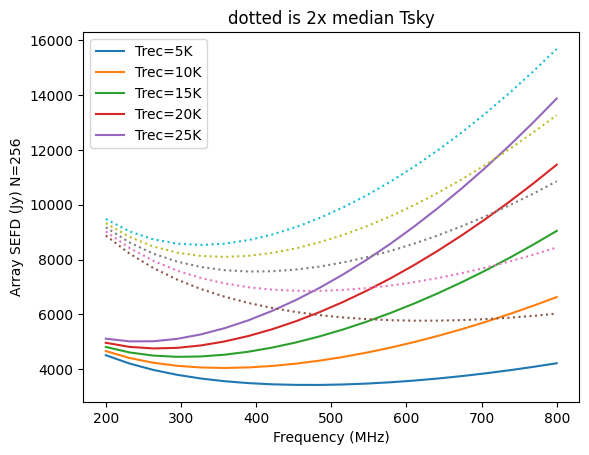

In [122]:
Trecs = [5,10,15,20,25]

SEFD = np.array([2*constants.k*(Trec + medskytemps)/aeff*1e26/(Npol*Nant) for Trec in Trecs])
SEFD2 = np.array([2*constants.k*(Trec + medskytemps*2)/aeff*1e26/(Npol*Nant) for Trec in Trecs])


plot(freqs, SEFD.T, label=f'Trec={Trec} K')
plot(freqs, SEFD2.T, label=f'Trec={Trec} K', ls=':')

labels = [f'Trec={Trec}K' for Trec in Trecs]
labels2 = [f'Trec={Trec}K Tsk' for Trec in Trecs]


xlabel('Frequency (MHz)')
ylabel(f'Array SEFD (Jy) N={Nant}')
legend(labels)
title('dotted is 2x median Tsky')

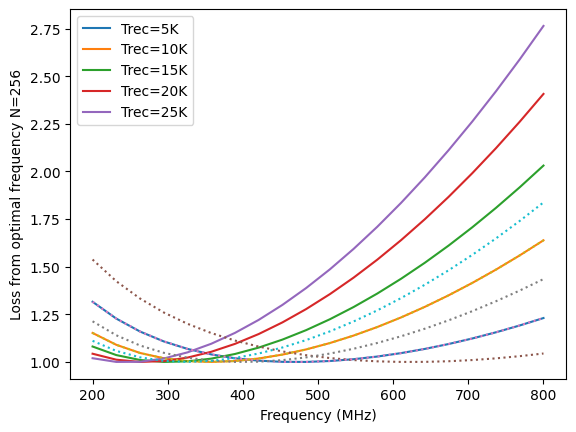

In [123]:
loss = SEFD/SEFD.min(axis=1)[:,np.newaxis]
loss2 = SEFD2/SEFD2.min(axis=1)[:,np.newaxis]


plot(freqs, loss.T, label=f'Trec={Trec} K')
plot(freqs, loss2.T, label=f'Trec={Trec} K', ls=':')

labels = [f'Trec={Trec}K' for Trec in Trecs]

xlabel('Frequency (MHz)')
ylabel(f'Loss from optimal frequency N={Nant}')
legend(labels)